# Masked tSZ power spectrum: detected-cluster mask vs completeness theory

We mask the **detected** clusters (catalogue SNR $q>q_{\rm cat}$) out of the Compton-$y$ map and measure the residual (unresolved) tSZ power spectrum. The halo-model prediction uses the Arnaud A10 GNFW pressure profile and down-weights the mass-redshift integrand by a **completeness function**: the probability that a halo of given $(M,z)$ is *not* detected, including log-normal intrinsic scatter in the $Y$-$M$ relation.

**Map side.** Cut a disc of radius $R_{\rm mask}\,\theta_{500}$ around every catalogue cluster with $q_{\rm from\,Y\,5R500c}>q_{\rm cat}$, apodize the mask, and estimate the **mask-decoupled** bandpowers with **NaMaster** (mode-coupling deconvolution; mask-weighted monopole subtracted), then deconvolve the pixel window.

**Theory side.** D3A cosmology, tSZ tracer with Arnaud A10 GNFW and $B=1.0$. The selection uses the **same GNFW** central $y_0(M,z)$ to form the SNR $q=y_0/\sigma_{y_0}$ (Planck SZiFi noise), and **scatter** completeness fractions in $[0,1]$ (the conditional moment normalised by the unconditional one), so the masked spectrum is bounded above by the unmasked one.

We plot $D_\ell=\ell(\ell+1)C_\ell/2\pi$ for the unmasked map, the masked map, and the masked theory.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

import jax.numpy as jnp

from flamingo import paths
from flamingo.maps import read_map
from flamingo.catalogue import load_catalogue, D3A_COSMOLOGY
from flamingo.geometry import query_disc_separation, ARCMIN_PER_RAD
from hmfast.halos import HaloModel, convert_m_delta, MassDefinition
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer
from hmfast.utils import Const
from hmfast.tracers.tsz_completeness import (
    compute_theta500_arcmin, load_sigma_y0_curve, sigma_y0_from_theta,
    conditional_An_undetected,
)

ymap = read_map(paths.HYDRO_MAP)
df = load_catalogue(paths.HYDRO_CATALOGUE)
NSIDE = hp.npix2nside(ymap.size)
print('NSIDE', NSIDE, '| clusters', len(df))


NSIDE 4096 | clusters 1555542


## Mask the detected clusters and measure the map power spectrum

Detected = catalogue $q_{\rm from\,Y\,5R500c}>q_{\rm cat}$. We zero a $R_{\rm mask}\,\theta_{500}$ disc around each, apodize the mask, and estimate the **mask-decoupled** bandpowers with **NaMaster** (proper mode-coupling deconvolution, with the mask-weighted monopole subtracted), then deconvolve the pixel window. A scalar $1/f_{\rm sky}$ rescale of a pseudo-$C_\ell$ would be biased by the mask's mode coupling, especially for a mask with many small holes.

In [ ]:
Q_CAT = 5.0          # detection / masking SNR threshold
R_MASK = 5.0         # mask radius in units of theta500
LMAX = 6000

detected = df[df['q_from_Y_5R500c'] > Q_CAT]
print(f'detected clusters (q>{Q_CAT}): {len(detected)}')

# Binary mask: zero a R_MASK*theta500 disc around each detected cluster.
mask = np.ones(ymap.size, dtype=np.float64)
for _, row in detected.iterrows():
    r_rad = R_MASK * float(row['theta500_arcmin']) / ARCMIN_PER_RAD
    pix, _ = query_disc_separation(NSIDE, float(row['theta_rot_rad']),
                                   float(row['phi_rot_rad']), r_rad)
    mask[pix] = 0.0
print(f'f_sky (binary) = {mask.mean():.4f}')

from flamingo.powerspectra import apodize, decoupled_dl
mask_apo = apodize(mask, aperture_deg=0.5)   # smooth taper for NaMaster

# Mask-decoupled bandpowers via NaMaster: proper mode-coupling deconvolution
# (NOT a scalar 1/fsky rescale), with the mask-weighted monopole subtracted
# internally. We then deconvolve the HEALPix pixel window. Unmasked = full sky.
DELL = 30
pwf = hp.pixwin(NSIDE, lmax=LMAX)


def dl_nmt(weight):
    ell_eff, _, cl = decoupled_dl(ymap, weight, delta_ell=DELL, lmax=LMAX)
    pw_eff = np.interp(ell_eff, np.arange(pwf.size), pwf)
    cl = cl / pw_eff**2
    return ell_eff, ell_eff * (ell_eff + 1) / (2 * np.pi) * cl


ellb, dl_unmasked_b = dl_nmt(None)           # full-sky reference
_, dl_masked_b = dl_nmt(mask_apo)            # detected-cluster mask

detected clusters (q>5.0): 1740


## Theory: Arnaud GNFW with the scatter completeness

The SNR field $q(M,z)=y_0/\sigma_{y_0}$ is built from the **same Arnaud GNFW** profile used for the power spectrum: $y_0(M,z)$ is the GNFW central Compton-$y$ (no separate parametric scaling relation), and $\sigma_{y_0}(\theta_{500})$ is the Planck SZiFi noise curve. The completeness weights are the conditional moments $\langle A^n\,\mathbf{1}(q_{\rm obs}<q_{\rm cat})\rangle$ with log-normal scatter $\sigma_{\ln Y}$, **normalised by the unconditional moment** $\langle A^n\rangle=e^{n^2\sigma_{\ln Y}^2/2}$ so they are proper completeness fractions in $[0,1]$ ($n=2$ for the 1-halo term, $n=1$ per 2-halo bracket). This guarantees the masked spectrum is bounded above by the unmasked one: masking can only remove power. We also show the unmasked theory for reference.

In [ ]:
# Arnaud A10 GNFW, B = 1.0, for the pressure (power-spectrum) side.
A10 = dict(P0=8.403, c500=1.177, gamma=0.3081, alpha=1.0510, beta=5.4905)
B = 1.0
tracer = tSZTracer(profile=GNFWPressureProfile(**A10, B=B))
hm = HaloModel(cosmology=D3A_COSMOLOGY)

SIGMA_LNY = 0.173                      # intrinsic log-normal Y-M scatter (Planck)

ell_th = jnp.logspace(1.0, np.log10(LMAX), 40)
m = jnp.logspace(11.0, 15.5, 60)      # physical Msun
z = jnp.geomspace(0.001, 3.0, 60)
# --- SNR field from the SAME Arnaud GNFW profile (not a parametric scaling) ---
# Central Compton-y0(M,z) of the Arnaud GNFW profile, matching the y0_orig used
# inside hmfast's GNFW pressure code: y0 = 2 (sigma_T/m_e c^2) P0 P_500c r_500c I_shape.
mdef500 = MassDefinition(500, 'critical')
c_old = hm.concentration.c_delta(hm, m, z)
m500c = convert_m_delta(hm.cosmology, m, z, hm.mass_definition, mdef500, c_old=c_old)  # (Nm,Nz)
r500c = mdef500.r_delta(hm.cosmology, m500c, z)                                        # physical Mpc
h = hm.cosmology.H0 / 100.0
E_z = jnp.atleast_1d(hm.cosmology.hubble_parameter(z))[None, :] / hm.cosmology.H0
P_500c = (1.65 * (h / 0.7) ** 2 * E_z ** (8.0 / 3.0)
          * ((m500c * h / B) / (0.7 * 3.0e14)) ** (2.0 / 3.0 + 0.12)
          * (0.7 / h) ** 1.5)
SIGMA_T_CM2, MEC2_EV, I_SHAPE = 6.6524587e-25, 510998.95, 0.470502095
y0 = (2.0 * (SIGMA_T_CM2 / MEC2_EV) * A10['P0'] * P_500c
      * (r500c * Const._Mpc_over_m_ * 100.0) * I_SHAPE)                                # (Nm,Nz)
theta500 = compute_theta500_arcmin(hm, m, z, B)                                        # arcmin
coeff, _ = load_sigma_y0_curve()                                                       # Planck SZiFi noise
snr = y0 / sigma_y0_from_theta(theta500, coeff)                                        # q(M,z)

# Completeness fraction in [0,1]: conditional moment <A^n 1(undetected)> normalised
# by the unconditional moment <A^n> = exp(n^2 sigma^2 / 2), so the masked spectrum is
# bounded above by the unmasked one by construction (masking can only remove power).
norm1 = np.exp(0.5 * (2 * SIGMA_LNY) ** 2)
norm2 = np.exp(0.5 * (1 * SIGMA_LNY) ** 2)
w1h = conditional_An_undetected(snr, SIGMA_LNY, Q_CAT, n_power=2) / norm1
w2h = conditional_An_undetected(snr, SIGMA_LNY, Q_CAT, n_power=1) / norm2

ell_np = np.asarray(ell_th)
pref_th = ell_np * (ell_np + 1) / (2 * np.pi)

# Masked (unresolved) theory.
cl1h_m = np.asarray(hm.cl_1h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=w1h))
cl2h_m = np.asarray(hm.cl_2h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=w2h))
dl_th_masked = pref_th * (cl1h_m + cl2h_m)

# Unmasked theory for reference.
cl1h = np.asarray(hm.cl_1h(tracer, tracer, l=ell_th, m=m, z=z))
cl2h = np.asarray(hm.cl_2h(tracer, tracer, l=ell_th, m=m, z=z))
dl_th_full = pref_th * (cl1h + cl2h)

print('SNR range:', float(snr.min()), float(snr.max()),
      '| completeness w1h in [%.2f, %.2f]' % (float(w1h.min()), float(w1h.max())))
print('masked/unmasked theory D_ell at ell~3000:',
      float(np.interp(3000, ell_np, dl_th_masked)),
      float(np.interp(3000, ell_np, dl_th_full)))

E0614 03:52:11.815364 2609272 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 71.23GiB (76478791680 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0614 03:52:11.815843 2609272 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 64.10GiB (68830912512 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0614 03:52:11.816183 2609272 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 57.69GiB (61947817984 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0614 03:52:11.816504 2609272 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 51.92GiB (55753035776 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0614 03:52:11.816822 2609272 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 46.73GiB (50177732608 by

SNR range: 8.430062903108342e-09 5565.966052191761 | completeness w1h in [0.00, 0.84]
masked/unmasked theory D_ell at ell~3000: 5.981135879209577e-13 1.5918300729577241e-12


In [ ]:
# --- Same masked-completeness theory, but with the Mira-Titan HMF ---
# Mira-Titan is native M200c and valid for z <= 2 and M200c >~ 1.5e13 Msun, so we
# use its own (m_mt, z_mt) grid. The SNR/completeness reuse cosmology + the Arnaud
# y0 (HMF-independent); only the mass function differs in cl_*_masked.
from hmfast.halos.massfunc import MTHaloMass

mt = MTHaloMass(); mt.prepare(D3A_COSMOLOGY)
hm_mt = HaloModel(cosmology=D3A_COSMOLOGY, halo_mass_function=mt)
z_mt = jnp.geomspace(0.001, 2.0, 60)
m_mt = jnp.logspace(np.log10(1.5e13), 15.5, 50)   # Mira-Titan valid mass range

c_old_mt = hm.concentration.c_delta(hm, m_mt, z_mt)
m500c_mt = convert_m_delta(hm.cosmology, m_mt, z_mt, hm.mass_definition, mdef500, c_old=c_old_mt)
r500c_mt = mdef500.r_delta(hm.cosmology, m500c_mt, z_mt)
E_mt = jnp.atleast_1d(hm.cosmology.hubble_parameter(z_mt))[None, :] / hm.cosmology.H0
P500_mt = (1.65 * (h / 0.7) ** 2 * E_mt ** (8.0 / 3.0)
           * ((m500c_mt * h / B) / (0.7 * 3.0e14)) ** (2.0 / 3.0 + 0.12) * (0.7 / h) ** 1.5)
y0_mt = (2.0 * (SIGMA_T_CM2 / MEC2_EV) * A10['P0'] * P500_mt
         * (r500c_mt * Const._Mpc_over_m_ * 100.0) * I_SHAPE)
snr_mt = y0_mt / sigma_y0_from_theta(compute_theta500_arcmin(hm, m_mt, z_mt, B), coeff)
w1h_mt = conditional_An_undetected(snr_mt, SIGMA_LNY, Q_CAT, n_power=2) / norm1
w2h_mt = conditional_An_undetected(snr_mt, SIGMA_LNY, Q_CAT, n_power=1) / norm2

cl1h_m_mt = np.asarray(hm_mt.cl_1h_masked(tracer, tracer, l=ell_th, m=m_mt, z=z_mt, mask_mz=w1h_mt))
cl2h_m_mt = np.asarray(hm_mt.cl_2h_masked(tracer, tracer, l=ell_th, m=m_mt, z=z_mt, mask_mz=w2h_mt))
dl_th_masked_mt = pref_th * (cl1h_m_mt + cl2h_m_mt)
print('Mira-Titan masked D_ell at ell~3000:', float(np.interp(3000, ell_np, dl_th_masked_mt)))

Mira-Titan masked D_ell at ell~3000: 5.936678385019614e-13


In [ ]:
# --- Low-ell (point-source) 1-halo normalization of the MASKED map ---
# After removing detected clusters (q>Q_CAT), the residual 1-halo white level is the
# point-source shot noise of the SURVIVING (undetected) clusters: C -> (1/4pi) sum_surv Y_ang^2.
from hmfast.halos.massfunc import T08HaloMass

_z = df['z'].values
_dA = df['r_comoving_Mpc'].values / (1 + _z)
y_ang = df['Y_5R500c_Mpc2'].values / _dA**2                  # integrated y [sr]
surv = df['q_from_Y_5R500c'].values < Q_CAT                  # undetected = survives the mask

C_white_cat = np.sum(y_ang[surv]**2) / (4 * np.pi)          # catalogue-direct

# Tinker08-HMF version: catalogue sum(Y^2) of survivors per (logM500c,z) bin, reweighted
# by the T08/catalogue count ratio so the number density comes from theory.
mE = np.arange(13.7, 15.7, 0.1); zE = np.linspace(0.0, 3.0, 31)
lm = np.log10(df['M_500c_Msun'].values)
Ssurv, _, _ = np.histogram2d(lm, _z, bins=[mE, zE], weights=np.where(surv, y_ang**2, 0.0))
Ncat, _, _ = np.histogram2d(lm, _z, bins=[mE, zE])
hm5w = HaloModel(cosmology=D3A_COSMOLOGY, mass_definition=MassDefinition(500, 'critical'),
                 halo_mass_function=T08HaloMass())
mc = 0.5 * (mE[:-1] + mE[1:]); zc = 0.5 * (zE[:-1] + zE[1:])
dnw = np.asarray(hm5w.halo_mass_function.halo_mass_function(hm5w, jnp.asarray(10**mc), jnp.asarray(zc)))
dVw = np.asarray(D3A_COSMOLOGY.comoving_volume_element(jnp.asarray(zc)))
N_T08 = 4 * np.pi * dVw[None, :] * dnw * (np.log(10) * 0.1) * (zE[1] - zE[0])
ratio = np.where(Ncat > 0, N_T08 / np.maximum(Ncat, 1), 0.0)
C_white_T08 = np.sum(Ssurv * ratio) / (4 * np.pi)

ell_w = np.logspace(1.0, np.log10(300.0), 40)
dl_white_cat = ell_w * (ell_w + 1) / (2 * np.pi) * C_white_cat
dl_white_T08 = ell_w * (ell_w + 1) / (2 * np.pi) * C_white_T08
print('masked C_white (undetected): cat=%.3e  Tinker08=%.3e' % (C_white_cat, C_white_T08))

masked C_white (undetected): cat=2.234e-18  Tinker08=2.301e-18


## $D_\ell$ vs $\ell$: masking suppresses the cluster-dominated small-scale power

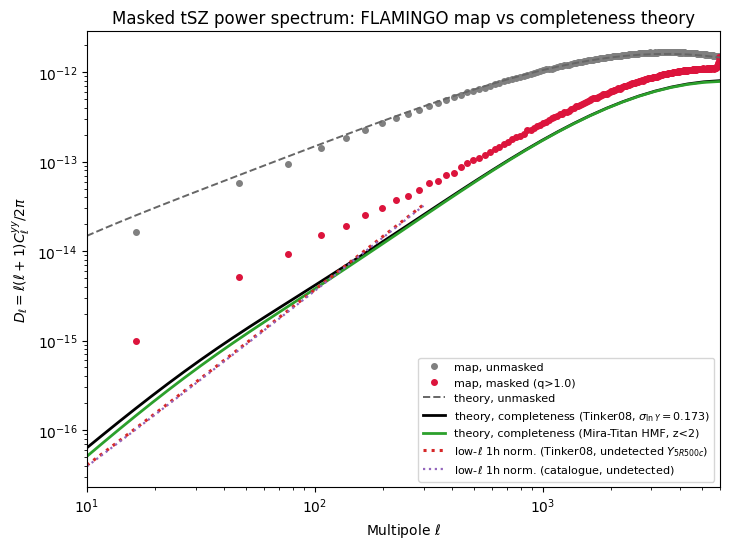

In [ ]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.loglog(ellb, dl_unmasked_b, 'o', ms=4, color='0.5', label='map, unmasked')
ax.loglog(ellb, dl_masked_b, 'o', ms=4, color='crimson',
          label=f'map, masked (q>{Q_CAT})')
ax.loglog(ell_np, dl_th_full, '--', lw=1.4, color='0.4', label='theory, unmasked')
ax.loglog(ell_np, dl_th_masked, 'k-', lw=2,
          label=r'theory, completeness (Tinker08, $\sigma_{\ln Y}=%.3f$)' % SIGMA_LNY)
ax.loglog(ell_np, dl_th_masked_mt, '-', lw=2, color='C2',
          label='theory, completeness (Mira-Titan HMF, z<2)')
ax.loglog(ell_w, dl_white_T08, ':', color='C3', lw=2.2,
          label=r'low-$\ell$ 1h norm. (Tinker08, undetected $Y_{5R500c}$)')
ax.loglog(ell_w, dl_white_cat, ':', color='C4', lw=1.6,
          label=r'low-$\ell$ 1h norm. (catalogue, undetected)')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell^{yy}/2\pi$')
ax.set_title('Masked tSZ power spectrum: FLAMINGO map vs completeness theory')
ax.set_xlim(10, LMAX)
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()